# Outlet Framing Analysis

Comparing frame usage between individual outlets and by political valence (Left, Center, Right).

In [1]:
%pip install pandas numpy matplotlib seaborn pyarrow scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

In [3]:
df = pd.read_parquet('../data/merged_topic_and_frames_filtered.parquet')
print(f'Loaded {len(df):,} articles')

frames = sorted(['economic', 'fairness', 'public_op', 'political', 'quality_life',
                 'crime', 'culture', 'health', 'legality', 'morality',
                 'policy', 'regulation', 'security', 'cap&res'])

frame_matrix = np.array(df['vector'].tolist())
for i, frame in enumerate(frames):
    df[f'frame_{frame}'] = frame_matrix[:, i]

frame_cols = [f'frame_{f}' for f in frames]

valence_map = {'Left': 'Left', 'Lean Left': 'Left', 'Center': 'Center', 'Lean Right': 'Right', 'Right': 'Right'}
df['valence'] = df['bias'].map(valence_map)

print(f'\nArticles by valence:')
print(df['valence'].value_counts())

Loaded 80,783 articles

Articles by valence:
valence
Left      33966
Right     29674
Center    17143
Name: count, dtype: int64


## Frame Usage by Individual Outlet

In [4]:
outlet_frames = df.groupby('outlet_name')[frame_cols].mean()
outlet_frames.columns = frames
outlet_frames['n_articles'] = df.groupby('outlet_name').size()
outlet_frames = outlet_frames.sort_values('n_articles', ascending=False)

outlet_frames.style.format('{:.1%}', subset=frames).format('{:,}', subset=['n_articles'])

,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security,n_articles
outlet_name,,,,,,,,,,,,,,,
Newsweek,4.0%,38.1%,21.1%,11.4%,37.7%,21.3%,68.2%,3.3%,59.5%,25.4%,31.7%,40.0%,22.2%,34.4%,"21,579"
Breitbart News,3.2%,45.6%,12.4%,9.6%,50.9%,11.5%,79.0%,6.1%,53.5%,37.8%,27.2%,17.3%,25.6%,37.1%,"14,671"
HuffPost,8.3%,22.6%,34.0%,16.9%,42.4%,25.1%,44.0%,4.8%,54.4%,19.0%,29.1%,59.1%,11.3%,14.7%,"9,617"
New York Post,5.0%,39.7%,20.5%,17.3%,32.2%,22.9%,60.5%,2.1%,47.8%,16.0%,23.6%,51.4%,9.3%,25.4%,"8,424"
CNBC,36.8%,7.9%,8.9%,71.5%,17.9%,14.6%,46.0%,0.3%,93.3%,9.0%,13.4%,55.9%,23.6%,21.6%,"7,957"
Reuters,31.9%,15.9%,4.7%,50.9%,18.6%,21.5%,64.8%,0.5%,86.2%,9.9%,8.2%,26.7%,43.7%,37.6%,"6,979"
Washington Times,4.1%,39.5%,11.9%,12.4%,43.1%,18.5%,80.3%,2.1%,62.6%,29.4%,21.8%,26.9%,19.3%,31.4%,"6,579"
The Washington Post,13.0%,22.1%,22.3%,23.6%,42.7%,16.2%,52.0%,3.1%,56.9%,30.5%,25.3%,41.2%,13.5%,19.1%,"2,770"
BBC News,4.2%,20.2%,21.1%,16.1%,17.3%,16.6%,33.8%,0.8%,64.7%,4.0%,13.5%,71.9%,15.0%,17.7%,"2,207"


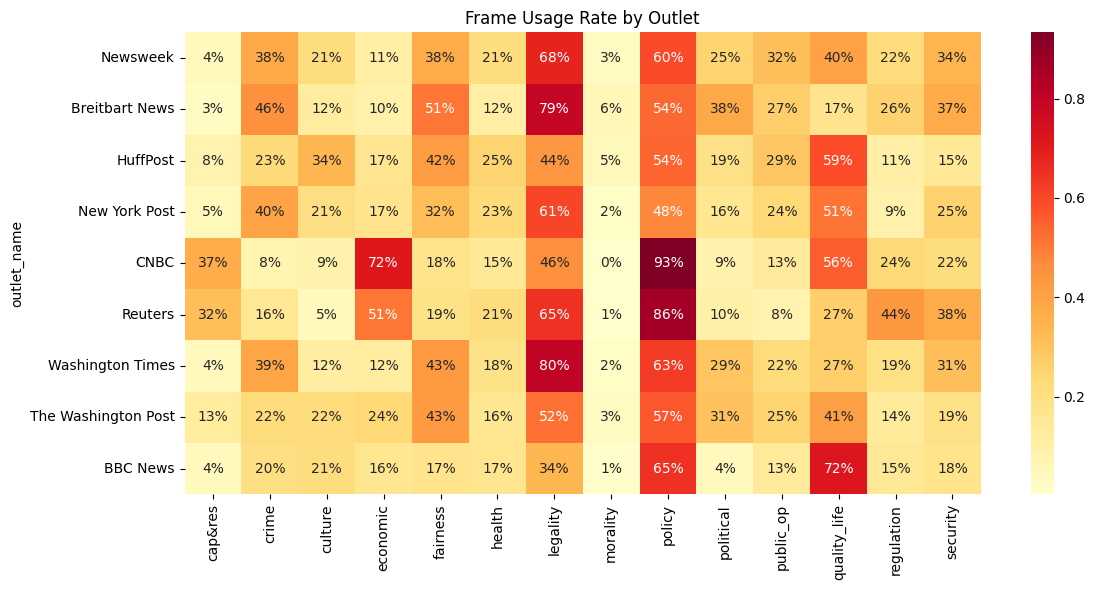

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(outlet_frames[frames], annot=True, fmt='.0%', cmap='YlOrRd', ax=ax)
plt.title('Frame Usage Rate by Outlet')
plt.tight_layout()
plt.show()

In [6]:
print('Frame usage range across outlets (max - min):\n')
for frame in frames:
    vals = outlet_frames[frame]
    print(f'{frame:15} {vals.min():.0%} - {vals.max():.0%}  (range: {vals.max()-vals.min():.0%})')

Frame usage range across outlets (max - min):

cap&res         3% - 37%  (range: 34%)
crime           8% - 46%  (range: 38%)
culture         5% - 34%  (range: 29%)
economic        10% - 72%  (range: 62%)
fairness        17% - 51%  (range: 34%)
health          12% - 25%  (range: 14%)
legality        34% - 80%  (range: 46%)
morality        0% - 6%  (range: 6%)
policy          48% - 93%  (range: 46%)
political       4% - 38%  (range: 34%)
public_op       8% - 32%  (range: 24%)
quality_life    17% - 72%  (range: 55%)
regulation      9% - 44%  (range: 34%)
security        15% - 38%  (range: 23%)


In [7]:
# Chi-square tests for outlet/frame associations
print('Statistical significance of outlet/frame associations:\n')
outlet_chi2_results = []
for frame in frames:
    col = f'frame_{frame}'
    contingency = pd.crosstab(df['outlet_name'], df[col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    outlet_chi2_results.append({'frame': frame, 'chi2': chi2, 'p_value': p, 'significant': p < 0.05})

outlet_chi2_df = pd.DataFrame(outlet_chi2_results).sort_values('chi2', ascending=False)
outlet_chi2_df.style.format({'chi2': '{:.1f}', 'p_value': '{:.2e}'})

Statistical significance of outlet-frame associations:



,frame,chi2,p_value,significant
3,economic,17980.1,0.00e+00,True
0,cap&res,11862.0,0.00e+00,True
11,quality_life,7846.3,0.00e+00,True
8,policy,6565.3,0.00e+00,True
6,legality,6188.0,0.00e+00,True
1,crime,5626.6,0.00e+00,True
9,political,4472.2,0.00e+00,True
4,fairness,4198.7,0.00e+00,True
12,regulation,3720.9,0.00e+00,True
2,culture,3700.4,0.00e+00,True


## Frame Usage by Political Valence

In [8]:
valence_frames = df.groupby('valence')[frame_cols].mean()
valence_frames.columns = frames
valence_frames['n_articles'] = df.groupby('valence').size()
valence_frames = valence_frames.loc[['Left', 'Center', 'Right']]

valence_frames.style.format('{:.1%}', subset=frames).format('{:,}', subset=['n_articles'])

,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security,n_articles
valence,,,,,,,,,,,,,,,
Left,5.9%,32.4%,24.8%,14.0%,39.5%,22.0%,60.0%,3.7%,57.9%,24.0%,30.4%,45.5%,18.4%,27.6%,"33,966"
Center,30.6%,12.7%,8.8%,56.0%,18.1%,17.6%,52.1%,0.5%,86.7%,8.7%,11.3%,46.1%,30.6%,27.6%,"17,143"
Right,3.9%,42.6%,14.6%,12.4%,43.9%,16.3%,74.1%,4.1%,53.9%,29.8%,25.0%,29.1%,19.6%,32.5%,"29,674"


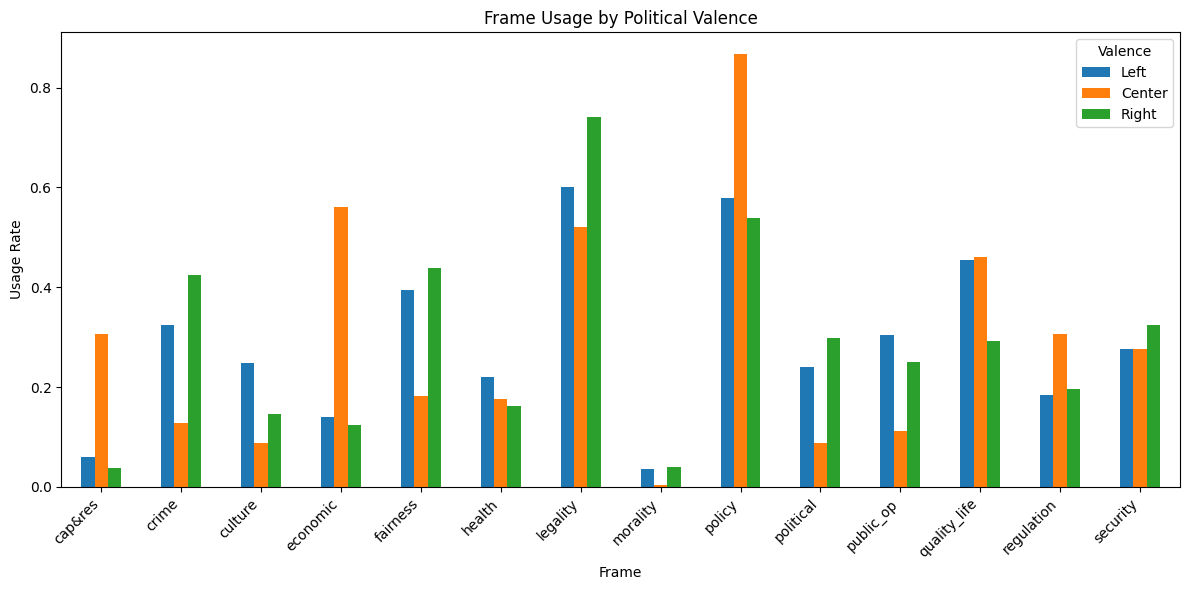

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
valence_frames[frames].T.plot(kind='bar', ax=ax)
plt.title('Frame Usage by Political Valence')
plt.xlabel('Frame')
plt.ylabel('Usage Rate')
plt.legend(title='Valence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# custom colormap to avoid red/blue political connotations
colors = ['#8B4513', '#FFFFFF', '#228B22']  # brown -> white -> green
cmap_neutral = LinearSegmentedColormap.from_list('BrownGreen', colors)

diff = valence_frames.loc['Left', frames] - valence_frames.loc['Right', frames]
diff_df = pd.DataFrame({'left_minus_right': diff}).sort_values('left_minus_right', key=abs, ascending=False)

print('Left vs Right frame usage difference:')
print('(positive/green = Left uses more, negative/brown = Right uses more)\n')
diff_df.style.format('{:+.1%}').background_gradient(cmap=cmap_neutral, vmin=-0.2, vmax=0.2)

Left vs Right frame usage difference:
(positive/green = Left uses more, negative/brown = Right uses more)



,left_minus_right
quality_life,+16.4%
legality,-14.1%
culture,+10.2%
crime,-10.2%
political,-5.8%
health,+5.7%
public_op,+5.5%
security,-4.9%
fairness,-4.4%
policy,+4.0%


## Statistical Significance: Chi-Square Tests (Valence vs Frame)

In [11]:
chi2_results = []
for frame in frames:
    col = f'frame_{frame}'
    contingency = pd.crosstab(df['valence'], df[col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({'frame': frame, 'chi2': chi2, 'p_value': p, 'significant': p < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2', ascending=False)
chi2_df.style.format({'chi2': '{:.1f}', 'p_value': '{:.2e}'})

,frame,chi2,p_value,significant
3,economic,14276.5,0.00e+00,True
0,cap&res,9557.1,0.00e+00,True
8,policy,5535.6,0.00e+00,True
1,crime,4451.5,0.00e+00,True
4,fairness,3312.5,0.00e+00,True
9,political,2771.5,0.00e+00,True
6,legality,2568.1,0.00e+00,True
2,culture,2328.5,0.00e+00,True
10,public_op,2276.9,0.00e+00,True
11,quality_life,2157.2,0.00e+00,True


## Frame Usage by Valence and Topic

In [12]:
topics = df['topic_top1'].value_counts().index.tolist()
print('Topics:', topics)

Topics: ['elections and politics', 'crime', 'entertainment', 'technology', 'finance', 'pandemic', 'healthcare', 'Middle East', 'immigration', 'China', 'Russia']


In [13]:
# Claude Code used to enhance print table readability 
def valence_comparison_for_topic(topic):
    subset = df[df['topic_top1'] == topic]
    valence_topic = subset.groupby('valence')[frame_cols].mean()
    valence_topic.columns = frames
    valence_topic = valence_topic.loc[['Left', 'Center', 'Right']]
    diff = valence_topic.loc['Left'] - valence_topic.loc['Right']
    return valence_topic, diff

for topic in topics[:4]:
    valence_topic, diff = valence_comparison_for_topic(topic)
    n = len(df[df['topic_top1'] == topic])
    print(f'\n=== {topic.upper()} (n={n:,}) ===')
    print('\nFrame usage by valence:')
    display(valence_topic.style.format('{:.1%}'))
    print('\nLargest Left-Right differences:')
    top_diff = diff.abs().sort_values(ascending=False).head(5)
    for frame in top_diff.index:
        print(f'  {frame}: {diff[frame]:+.1%}')


=== ELECTIONS AND POLITICS (n=15,114) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,0.6%,31.4%,11.2%,7.3%,73.1%,4.6%,84.1%,4.4%,55.1%,76.5%,48.7%,10.0%,21.3%,17.4%
Center,4.9%,19.1%,4.0%,25.9%,55.1%,5.1%,85.2%,0.7%,76.1%,62.3%,31.9%,10.6%,38.7%,25.2%
Right,0.6%,28.2%,8.1%,7.1%,71.6%,3.7%,82.9%,4.1%,54.3%,76.5%,43.0%,8.9%,19.4%,15.6%



Largest Left-Right differences:
  public_op: +5.7%
  crime: +3.2%
  culture: +3.1%
  regulation: +1.9%
  security: +1.8%

=== CRIME (n=13,084) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,0.4%,92.8%,11.0%,1.7%,41.0%,13.3%,87.0%,6.2%,39.3%,10.6%,14.3%,31.1%,9.6%,51.6%
Center,0.6%,88.0%,5.3%,5.5%,29.3%,7.6%,82.3%,2.2%,55.1%,9.1%,8.1%,24.2%,21.7%,49.7%
Right,0.2%,95.6%,5.7%,1.3%,32.4%,10.8%,86.4%,4.1%,31.3%,9.9%,8.2%,21.1%,7.7%,52.8%



Largest Left-Right differences:
  quality_life: +10.0%
  fairness: +8.7%
  policy: +8.1%
  public_op: +6.1%
  culture: +5.3%

=== ENTERTAINMENT (n=12,936) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,1.3%,15.5%,63.2%,6.5%,24.8%,15.3%,26.6%,4.5%,47.6%,10.7%,49.8%,80.2%,8.7%,8.8%
Center,5.1%,13.6%,43.0%,25.5%,14.3%,10.6%,23.4%,1.1%,67.5%,4.5%,27.3%,85.2%,19.2%,16.6%
Right,1.4%,22.4%,51.9%,8.6%,32.9%,13.6%,43.7%,7.0%,44.1%,22.0%,49.9%,68.7%,12.2%,11.6%



Largest Left-Right differences:
  legality: -17.2%
  quality_life: +11.4%
  culture: +11.4%
  political: -11.3%
  fairness: -8.1%

=== TECHNOLOGY (n=11,271) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,17.2%,17.6%,22.9%,30.2%,18.1%,27.2%,43.2%,1.5%,73.5%,5.9%,22.1%,62.2%,17.8%,32.5%
Center,34.4%,9.1%,11.2%,58.6%,9.5%,12.9%,43.3%,0.3%,92.6%,2.8%,10.7%,54.5%,37.4%,25.0%
Right,8.6%,28.0%,15.0%,19.2%,26.1%,22.1%,62.5%,2.2%,68.6%,14.4%,22.5%,41.8%,23.0%,36.1%



Largest Left-Right differences:
  quality_life: +20.4%
  legality: -19.3%
  economic: +11.0%
  crime: -10.4%
  cap&res: +8.6%


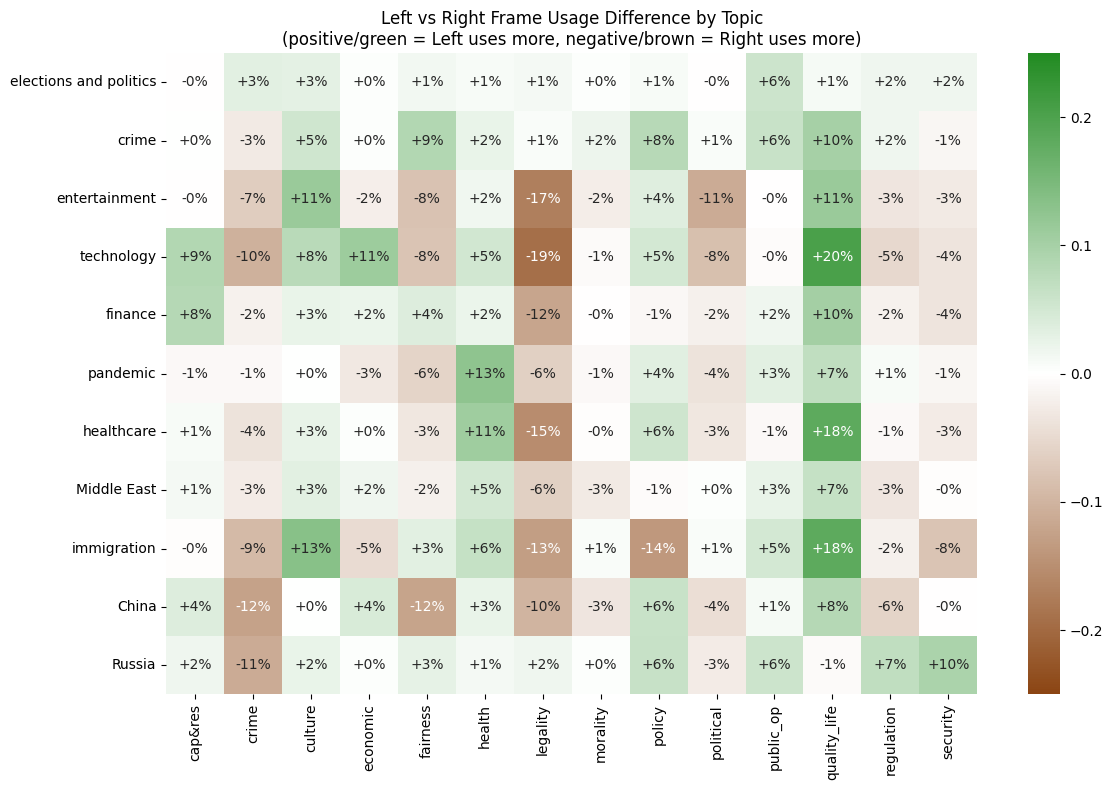

In [14]:
diff_by_topic = []
for topic in topics:
    _, diff = valence_comparison_for_topic(topic)
    diff_by_topic.append(diff)

diff_matrix = pd.DataFrame(diff_by_topic, index=topics)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(diff_matrix, annot=True, fmt='+.0%', cmap=cmap_neutral, center=0, ax=ax, vmin=-0.25, vmax=0.25)
plt.title('Left vs Right Frame Usage Difference by Topic\n(positive/green = Left uses more, negative/brown = Right uses more)')
plt.tight_layout()
plt.show()

## Frame Trends Over Time by Outlet

In [15]:
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = df['date'].dt.to_period('Q')

outlet_trends = []
for outlet in df['outlet_name'].unique():
    subset = df[df['outlet_name'] == outlet]
    quarterly = subset.groupby('quarter')[frame_cols].mean()
    x = np.arange(len(quarterly))

    for frame_col in frame_cols:
        y = quarterly[frame_col].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        outlet_trends.append({'outlet': outlet, 'frame': frame_col.replace('frame_', ''), 'slope_per_year': slope * 4, 'p_value': p_value})

outlet_trend_df = pd.DataFrame(outlet_trends)
outlet_trend_pivot = outlet_trend_df.pivot(index='outlet', columns='frame', values='slope_per_year')
outlet_trend_pivot = outlet_trend_pivot[frames]
outlet_trend_pivot.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.05, vmax=0.05)

frame,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
outlet,,,,,,,,,,,,,,
BBC News,-0.7%,+2.1%,+3.7%,+1.1%,-1.4%,+0.4%,-3.5%,+0.2%,-2.7%,-0.4%,-2.0%,+3.5%,-1.4%,+2.7%
Breitbart News,+0.1%,-0.2%,-1.3%,-0.0%,-0.0%,+1.7%,+1.3%,-0.1%,+0.6%,-0.6%,-1.8%,-0.2%,+0.3%,+0.2%
CNBC,-0.2%,+0.1%,-0.5%,-1.8%,+0.3%,+2.2%,+1.1%,-0.0%,+0.6%,-0.4%,-0.6%,+1.1%,+0.8%,+0.0%
HuffPost,-1.4%,+3.7%,-3.0%,-2.2%,+0.4%,-0.0%,+5.4%,-0.3%,-1.3%,+2.5%,+0.1%,-4.9%,+0.3%,+2.6%
New York Post,-0.0%,-0.6%,-1.4%,-1.1%,-0.8%,+2.8%,+0.3%,-0.0%,+1.4%,+0.2%,-0.7%,-1.2%,+0.5%,+1.3%
Newsweek,-0.1%,-0.6%,-0.5%,-0.9%,+0.5%,+2.5%,-0.7%,+0.0%,+0.3%,-0.2%,+0.6%,+1.5%,-2.7%,-2.0%
Reuters,+1.4%,-1.4%,-0.4%,+1.3%,-1.0%,+2.3%,-2.0%,-0.0%,+0.5%,-1.1%,-0.1%,+0.5%,-1.8%,+0.3%
The Washington Post,+3.2%,-1.7%,-0.4%,+2.2%,-3.5%,+1.6%,-5.1%,-0.3%,-2.0%,-3.1%,-2.4%,+2.1%,-1.7%,-1.3%
Washington Times,+0.3%,-1.3%,-0.7%,+0.2%,+1.3%,+1.1%,+0.1%,-0.1%,+0.4%,+0.9%,-0.7%,+0.3%,+0.7%,+0.4%


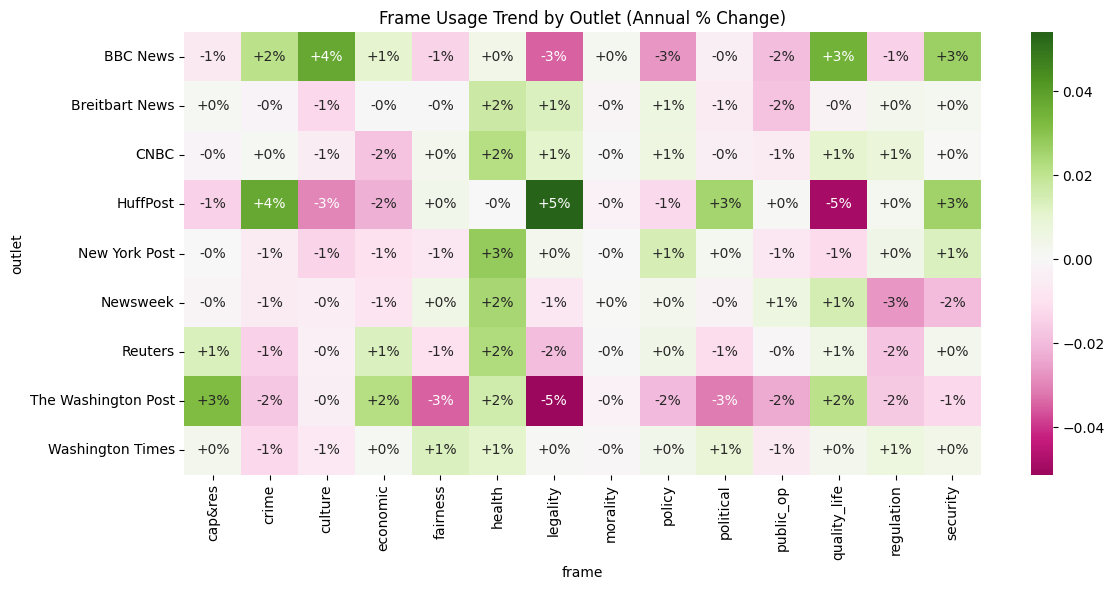

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(outlet_trend_pivot, annot=True, fmt='+.0%', cmap='PiYG', center=0, ax=ax)
plt.title('Frame Usage Trend by Outlet (Annual % Change)')
plt.tight_layout()
plt.show()

## Frame Trends Over Time by Political Valence

In [17]:
valence_trends = []
for valence in ['Left', 'Center', 'Right']:
    subset = df[df['valence'] == valence]
    quarterly = subset.groupby('quarter')[frame_cols].mean()
    x = np.arange(len(quarterly))

    for frame_col in frame_cols:
        y = quarterly[frame_col].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        valence_trends.append({'valence': valence, 'frame': frame_col.replace('frame_', ''), 'slope_per_year': slope * 4, 'p_value': p_value})

valence_trend_df = pd.DataFrame(valence_trends)
valence_trend_pivot = valence_trend_df.pivot(index='valence', columns='frame', values='slope_per_year')
valence_trend_pivot = valence_trend_pivot.loc[['Left', 'Center', 'Right'], frames]
valence_trend_pivot.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.03, vmax=0.03)

frame,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,-0.5%,+1.4%,-1.7%,-1.3%,-0.1%,+1.5%,+2.2%,-0.2%,+0.0%,+0.6%,+0.5%,-1.4%,-0.7%,+0.8%
Center,+2.0%,-0.6%,-0.3%,+2.4%,-0.3%,+2.0%,+0.2%,-0.0%,+1.4%,-0.3%,-0.8%,-0.2%,+0.4%,+1.0%
Right,+0.2%,-0.5%,-0.9%,-0.1%,-0.1%,+1.8%,+0.5%,-0.1%,+0.5%,-0.3%,-1.3%,+0.2%,+0.3%,+0.5%


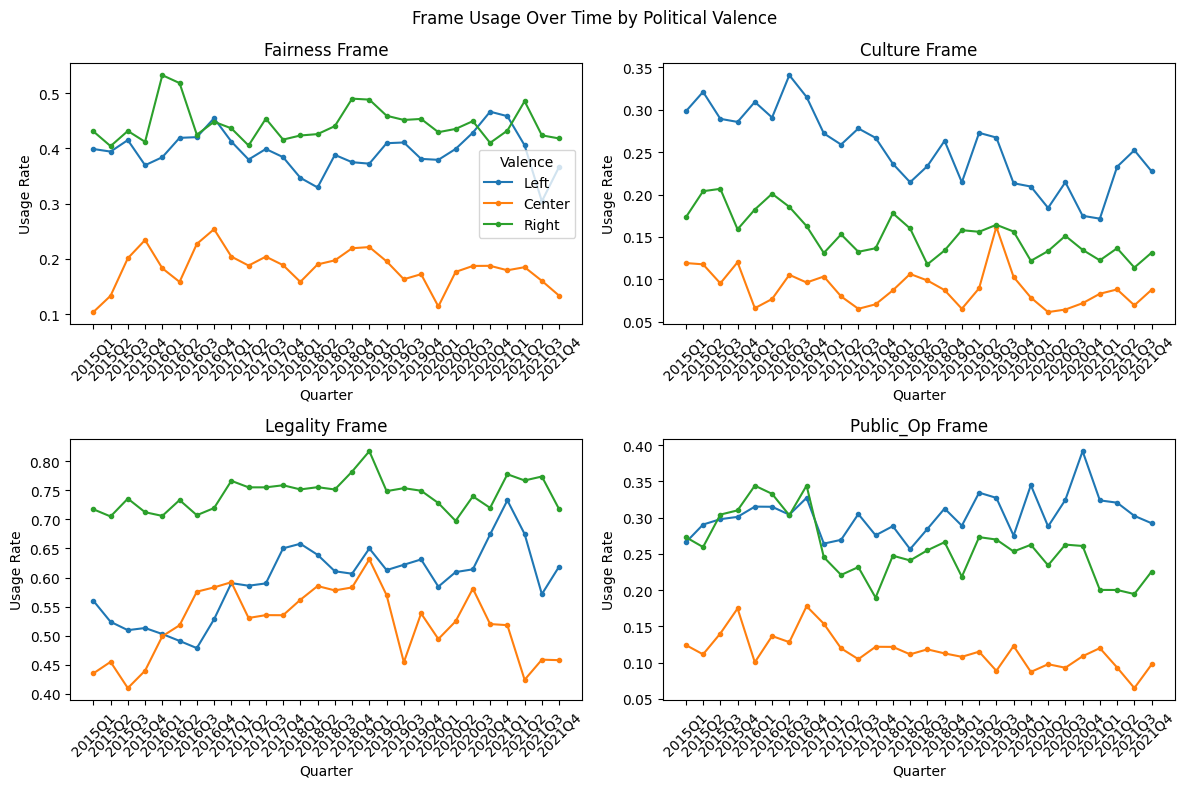

In [18]:
key_frames = ['fairness', 'culture', 'legality', 'public_op']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, frame in enumerate(key_frames):
    frame_col = f'frame_{frame}'
    ax = axes[idx]

    for valence in ['Left', 'Center', 'Right']:
        subset = df[df['valence'] == valence]
        quarterly = subset.groupby('quarter')[frame_col].mean()
        ax.plot(quarterly.index.astype(str), quarterly.values, label=valence, marker='o', markersize=3)

    ax.set_title(f'{frame.title()} Frame')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Usage Rate')
    ax.tick_params(axis='x', rotation=45)

axes[0].legend(title='Valence')
plt.suptitle('Frame Usage Over Time by Political Valence', fontsize=12)
plt.tight_layout()
plt.show()

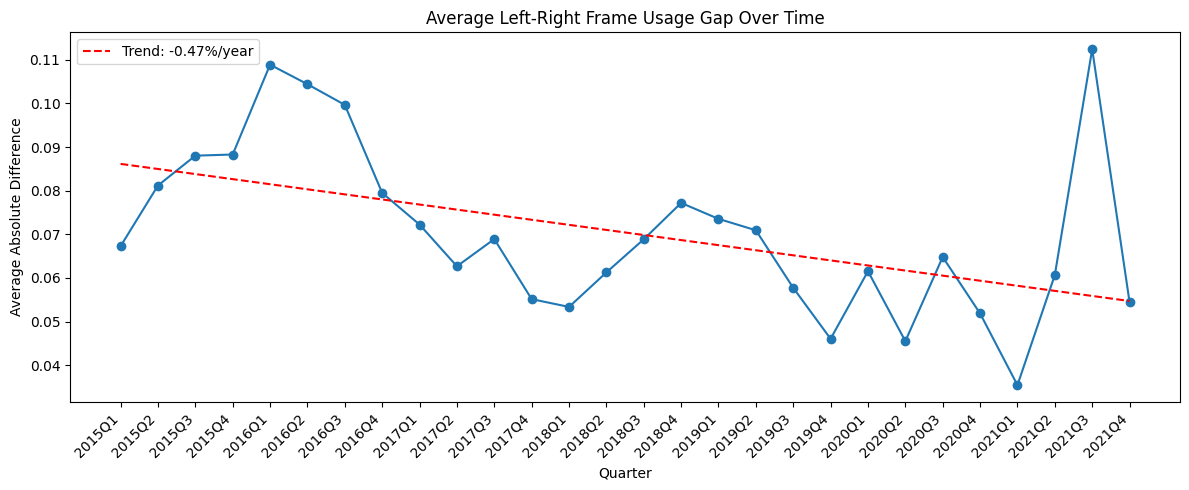

Gap trend: -0.47% per year (p=0.0078)
Left and Right outlets are converging in their framing over time


In [19]:
# check if valences are converging or diverging
quarterly_gap = []
for quarter in sorted(df['quarter'].unique()):
    q_df = df[df['quarter'] == quarter]
    left_mean = q_df[q_df['valence'] == 'Left'][frame_cols].mean()
    right_mean = q_df[q_df['valence'] == 'Right'][frame_cols].mean()
    gap = (left_mean - right_mean).abs().mean()
    quarterly_gap.append({'quarter': quarter, 'avg_gap': gap})

gap_df = pd.DataFrame(quarterly_gap).sort_values('quarter')
x = np.arange(len(gap_df))
y = gap_df['avg_gap'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gap_df['quarter'].astype(str), gap_df['avg_gap'], marker='o')
ax.plot(gap_df['quarter'].astype(str), intercept + slope * x, 'r--', label=f'Trend: {slope*4:+.2%}/year')
plt.title('Average Left/Right Frame Usage Gap Over Time')
plt.xlabel('Quarter')
plt.ylabel('Average Absolute Difference')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Gap trend: {slope*4:+.2%} per year (p={p_value:.4f})')
if slope > 0:
    print('Left and Right outlets are diverging in their framing over time')
else:
    print('Left and Right outlets are converging in their framing over time')